In [ ]:
# ── 0) INSTALLAZIONE E IMPORT ────────────────────────────────────────────────
!pip install transformers huggingface_hub nltk pandas tqdm -q

import os
import re
import pandas as pd
import torch
import nltk
from huggingface_hub import login
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm.auto import tqdm  # Usiamo tqdm.auto per l'integrazione con pandas

# Monta Google Drive (opzionale, ma consigliato per file persistenti)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive montato.")
except ImportError:
    print("Google Drive non disponibile. I file saranno salvati nella sessione temporanea.")

# ── 1) AUTENTICAZIONE ──────────────────────────────────────────────────────
try:
    from google.colab import userdata
    HF_API_KEY = userdata.get('HF_TOKEN').strip()
    if HF_API_KEY:
        login(token=HF_API_KEY)
        print("Login a Hugging Face effettuato con successo.")
    else:
        print("Secret 'HF_TOKEN' non trovato. Procedo senza login (potrebbe fallire per modelli privati).")
except ImportError:
    print("Non in Colab, saltare il login con userdata.")
except Exception as e:
    print(f"Errore durante il login a Hugging Face: {e}")

Mounted at /content/drive
Google Drive montato.
Login a Hugging Face effettuato con successo.


In [ ]:
#@title Configurazione dei percorsi e del modello
#@markdown Inserisci i percorsi dei file CSV, **separati da una virgola**.
#@markdown Esempio: `/path/file1.csv, /path/file2.csv`
#@markdown Se usi Google Drive, il percorso dovrebbe iniziare con `/content/drive/MyDrive/...`

INPUT_FILES_STRING = " /content/perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv" #@param {type:"string"}
OUTPUT_DIR = "/content/drive/MyDrive/data/results_replikaU/"     #@param {type:"string"}
MODEL_ID = "michellejieli/NSFW_text_classifier"      #@param {type:"string"}
BATCH_SIZE = 64                                       #@param {type:"integer"}

In [ ]:
# ── 2) IMPOSTAZIONE DEL DEVICE ───────────────────────────────────────────────────
# Modifica Colab: Usa cuda:0 se disponibile
DEVICE_ID = 0
device = torch.device(f"cuda:{DEVICE_ID}" if torch.cuda.is_available() else "cpu")
print(f"Using device = {device}")

# ── 3) NLTK SETUP ───────────────────────────────────────────────────────────
print("Download delle risorse NLTK (una tantum)...")
nltk.download("punkt",    quiet=True)
nltk.download("stopwords",quiet=True)
nltk.download("wordnet",  quiet=True)
nltk.download("punkt_tab", quiet=True) # Added to fix LookupError
lemmatizer     = WordNetLemmatizer()
stop_words     = set(stopwords.words("english"))
stopwords_list = [
    "i","me","my","myself","we","our","ours","ourselves",
    "you","your","yours","yourself","yourselves","he","him",
    "his","himself","she","her","hers","herself","it","its",
    "itself","they","them","their","themselves","what",
    "which","who","whom","this","that","these","those","am",
    "is","are","was","were","be","been","being","have","has",
    "had","having","do","does","did","doing","a","an","the",
    "and","but","if","or","because","as","until","while","of",
    "at","by","for","with","about","against","between","into",
    "through","during","before","after","above","below","to",
    "from","up","down","in","out","on","off","over","under",
    "again","further","then","once","here","there","when",
    "where","why","how","all","any","both","each","few","more",
    "most","other","some","such","no","nor","not","only","own",
    "same","so","than","too","very","s","t","can","will",
    "just","don","should","now"
]

def clean_text(text: str) -> str:
    """Lowercase, strip URLs/HTML, remove punctuation, lemmatize & drop stopwords."""
    if pd.isna(text):
        return ""
    text = re.sub(r"http\S+|www\S+|t\.co\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\/?[ru]\/\w+", "", text)
    text = re.sub(r"&gt;|&lt;|&amp;", "", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    tokens = word_tokenize(text)
    return " ".join(
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and tok not in stopwords_list
    )

# ── 6-7) CARICAMENTO MODELLO E PIPELINE (UNA SOLA VOLTA) ───────────────────────
print(f"Caricamento del modello {MODEL_ID} (una tantum)...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)
model.to(device)
model.eval()

print("Costruzione della pipeline (una tantum)...")
classifier = pipeline(
    task="sentiment-analysis",     # per NSFW_text_classifier
    model=model,
    tokenizer=tokenizer,
    device=DEVICE_ID               # Passa 0 per cuda:0
)
print("Setup completato. Inizio elaborazione file.")

# ── CICLO DI ELABORAZIONE PER OGNI FILE ────────────────────────────────────────
# Converte la stringa di input in un elenco di percorsi
input_files = [path.strip() for path in INPUT_FILES_STRING.split(',') if path.strip()]

if not input_files:
    print("Nessun file di input specificato. Controlla la Cella 2.")
else:
    print(f"Trovati {len(input_files)} file da elaborare.")

# Itera su ogni percorso di file fornito
for input_csv_path in input_files:
    print(f"\n{'='*60}")
    print(f"INIZIO ELABORAZIONE: {input_csv_path}")
    print(f"{'='*60}")

    # ── 4) CARICAMENTO CSV E FILTRO (per file) ──────────────────────────
    print(f"Caricamento dati da {input_csv_path}...")
    try:
        df = pd.read_csv(input_csv_path)
        df = df[df["text"].notna() & df["text"].str.strip().ne("")].reset_index(drop=True)

        if df.empty:
            print(f"ATTENZIONE: Nessun testo valido trovato in {input_csv_path}. Salto il file.")
            continue # Salta al prossimo file nel ciclo

        print(f"Caricate {len(df)} righe valide.")
    except FileNotFoundError:
        print(f"ERRORE: File non trovato a {input_csv_path}. Salto questo file.")
        continue # Salta al prossimo file nel ciclo
    except Exception as e:
        print(f"ERRORE durante la lettura di {input_csv_path}: {e}. Salto questo file.")
        continue # Salta al prossimo file nel ciclo

    # ── 5) PULIZIA DEL TESTO (per file) ──────────────────────────────────
    print("Avvio della pulizia del testo...")
    tqdm.pandas(desc=f"Cleaning {os.path.basename(input_csv_path)}")
    df["cleaned_text"] = df["text"].progress_apply(clean_text)
    cleaned = df["cleaned_text"].tolist()
    print("Pulizia del testo completata.")

    # ── 8) INFERENZA (per file) ──────────────────────────────────────────
    print("Avvio classificazione...")
    all_results = []
    for i in tqdm(range(0, len(cleaned), BATCH_SIZE), desc=f"Classifying {os.path.basename(input_csv_path)}"):
        batch = cleaned[i : i + BATCH_SIZE]
        all_results.extend(classifier(batch, truncation=True, batch_size=BATCH_SIZE))

    df["label"] = [r["label"] for r in all_results]
    df["score"] = [r["score"] for r in all_results]
    print("Classificazione completata.")

    # ── 9) SCRITTURA OUTPUT (per file) ───────────────────────────────────
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    basename    = os.path.basename(input_csv_path) # Il nome del file originale
    output_path = os.path.join(OUTPUT_DIR, basename)

    df.to_csv(output_path, index=False)
    print(f"Risultati salvati in {output_path}")
    print(f"--- FINE ELABORAZIONE: {input_csv_path} ---")

print("\nElaborazione di tutti i file terminata.")

Using device = cuda:0
Download delle risorse NLTK (una tantum)...
Caricamento del modello michellejieli/NSFW_text_classifier (una tantum)...


Device set to use cuda:0


Costruzione della pipeline (una tantum)...
Setup completato. Inizio elaborazione file.
Trovati 1 file da elaborare.

INIZIO ELABORAZIONE: /content/perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv
Caricamento dati da /content/perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv...
Caricate 9045 righe valide.
Avvio della pulizia del testo...


Cleaning perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv:   0%|          | 0/9045 [00:00<?, ?it/s…

Pulizia del testo completata.
Avvio classificazione...


Classifying perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv:   0%|          | 0/142 [00:00<?, ?it…

Classificazione completata.
Risultati salvati in /content/drive/MyDrive/data/results_replikaU/perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv
--- FINE ELABORAZIONE: /content/perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv ---

Elaborazione di tutti i file terminata.


In [ ]:
# ── 10) INSTALLAZIONE E IMPORT PER ANALISI ───────────────────────────────────
!pip install wordcloud -q

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import numpy as np
import warnings

# Configurazione stile grafici
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
warnings.filterwarnings('ignore')

print("Librerie di analisi caricate.")

Librerie di analisi caricate.


In [ ]:
# ── 11) CARICAMENTO DATI CONSOLIDATO ───────────────────────────────────────
# Usiamo le variabili 'input_files' e 'OUTPUT_DIR' definite nella Cella 2 e 3

all_dfs = []
processed_files_paths = []

# 'input_files' è l'elenco dei percorsi originali
# 'OUTPUT_DIR' è la nostra cartella dei risultati

print(f"Controllo {OUTPUT_DIR} per i file di risultato...")

for original_file_path in input_files:
    basename = os.path.basename(original_file_path)
    processed_path = os.path.join(OUTPUT_DIR, basename)

    if os.path.exists(processed_path):
        print(f"Caricamento: {processed_path}")
        try:
            temp_df = pd.read_csv(processed_path)
            all_dfs.append(temp_df)
            processed_files_paths.append(processed_path)
        except Exception as e:
            print(f"  Errore nel caricamento di {processed_path}: {e}")
    else:
        print(f"ATTENZIONE: File di risultato non trovato: {processed_path}. Salto.")

# Creiamo il DataFrame principale se abbiamo trovato dei file
if not all_dfs:
    print("\nERRORE: Nessun file di risultato trovato.")
    print("Assicurati di aver eseguito la Cella 3 e che i percorsi siano corretti.")
else:
    df = pd.concat(all_dfs, ignore_index=True)
    print(f"\nCaricamento completato.")
    print(f"Caricati {len(df):,} record totali da {len(all_dfs)} file.")
    print(f"Colonne disponibili: {list(df.columns)}")

Controllo /content/drive/MyDrive/data/results_replikaU/ per i file di risultato...
Caricamento: /content/drive/MyDrive/data/results_replikaU/perspective_moderated_human_ai_chatlogs_replikaU_cleaned.csv

Caricamento completato.
Caricati 9,045 record totali da 1 file.
Colonne disponibili: ['conversation_id', 'party', 'text', 'THREAT', 'SEVERE_TOXICITY', 'IDENTITY_ATTACK', 'INSULT', 'PROFANITY', 'TOXICITY', 'turn', 'cleaned_text', 'label', 'score']


Avvio dell'analisi sul DataFrame consolidato...
ANALISI NSFW/SFW CHAT DATASET

Dataset: 9,045 messaggi totali.
2432 conversazioni uniche.
Range turn: 1 - 21

1. ANALISI DI DISTRIBUZIONE NSFW/SFW

Distribuzione messaggi:
  NSFW: 6,122 (67.68%)
  SFW: 2,923 (32.32%)

Distribuzione per ruolo:
label     NSFW    SFW
party                
Chatbot  65.18  34.82
USER     71.51  28.49

✓ Salvato: /content/drive/MyDrive/data/results_replikaU/01_distribuzione_generale.png


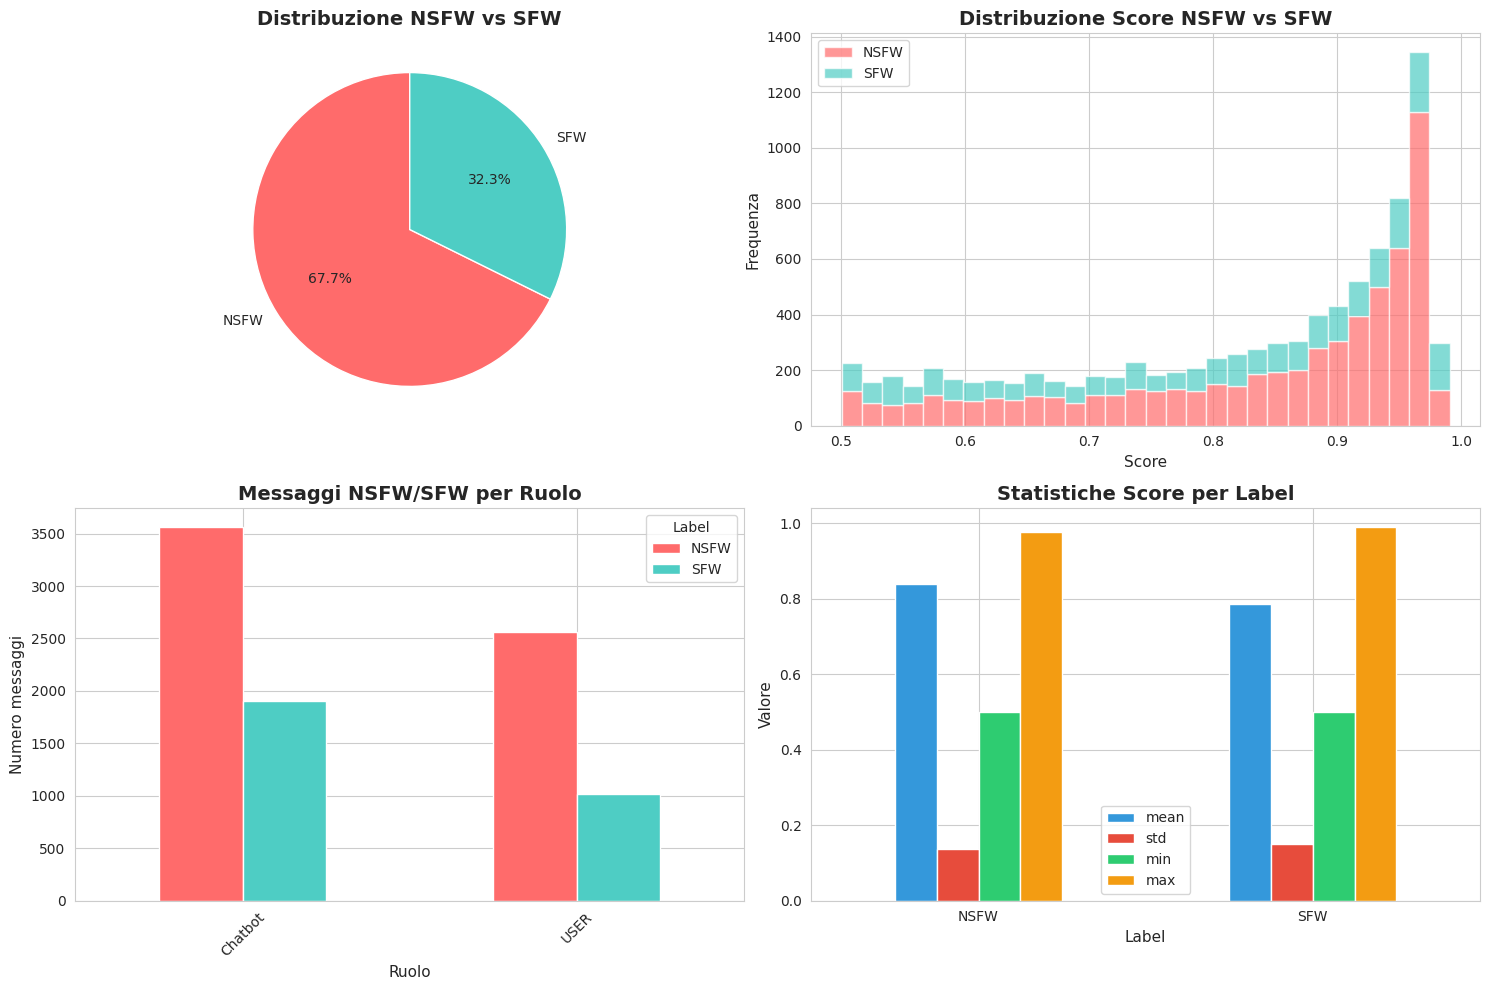


2. ANALISI PER RUOLO E PATTERN DI ESCALATION

Nessun pattern 'USER' -> 'Chatbot' trovato.

--- PATTERN DI ESCALATION ---

Conversazioni con escalation (SFW → NSFW): 652
Turn medio prima escalation: 2.4
Turn mediano: 2.0

✓ Salvato: /content/drive/MyDrive/data/results_replikaU/02_analisi_ruolo_escalation.png


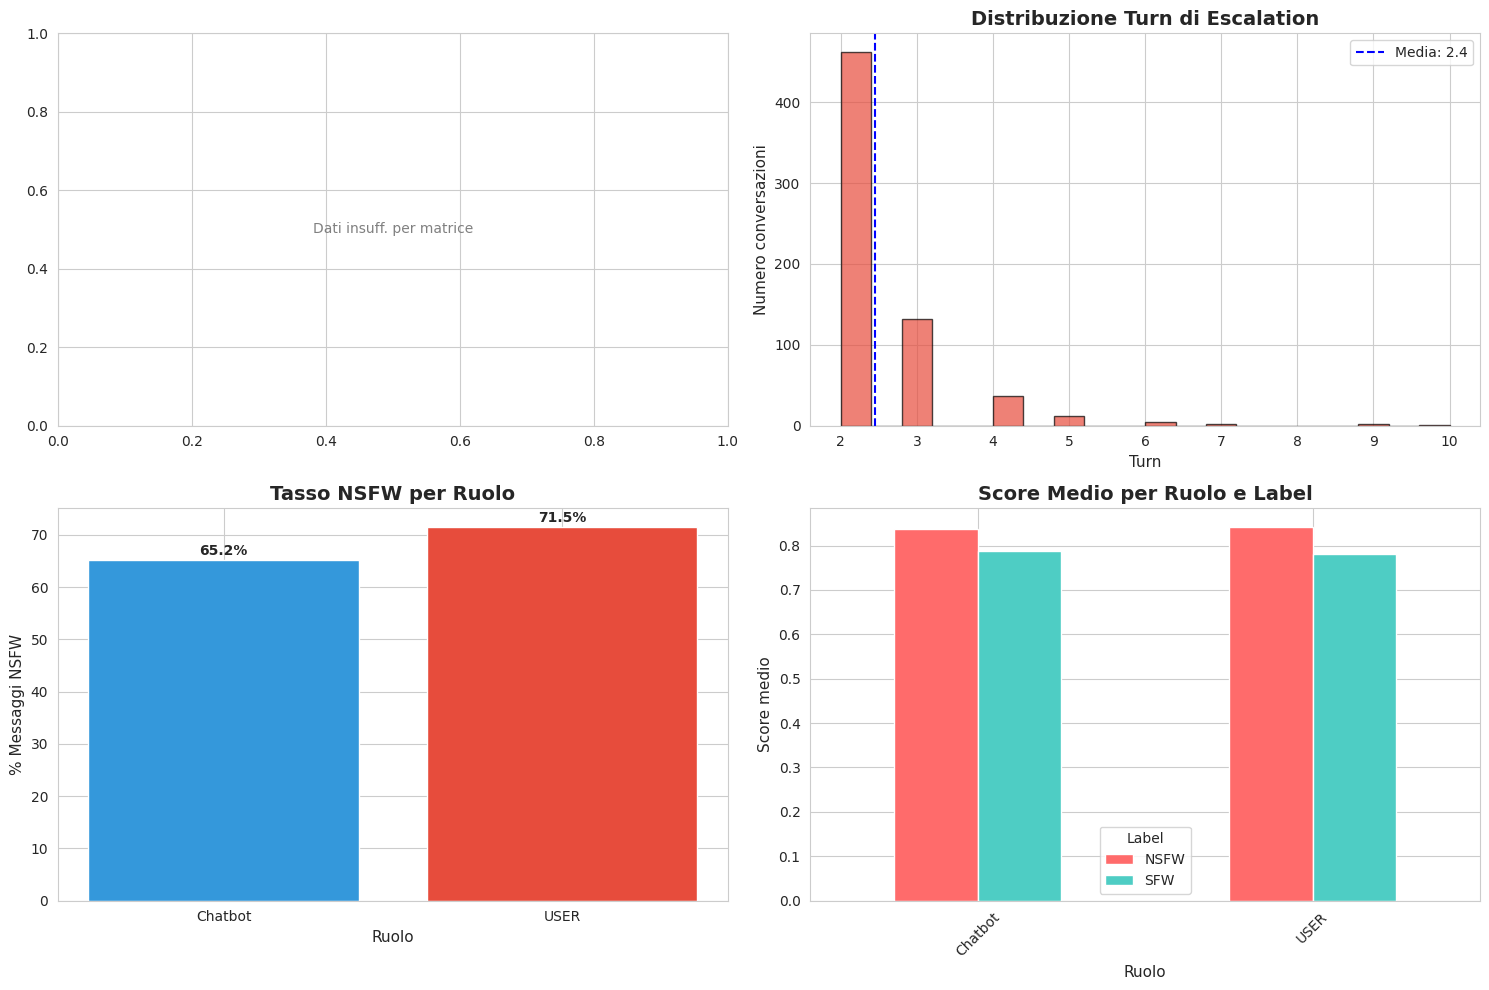


3. ANALISI TEMPORALE

Conversazioni che iniziano NSFW: 1628 (66.9%)
Conversazioni che iniziano SFW: 804 (33.1%)

--- PERSISTENZA NSFW ---
Conversazioni NSFW dall'inizio: 1628
% media messaggi NSFW in queste conversazioni: 83.5%

--- SEQUENZE NSFW CONSECUTIVE ---
Sequenze NSFW consecutive trovate: 2280
Lunghezza media: 2.3 messaggi
Sequenza più lunga: 11 messaggi
Distribuzione lunghezze: [(1, 806), (2, 683), (3, 432), (4, 214), (5, 84)]

✓ Salvato: /content/drive/MyDrive/data/results_replikaU/03_analisi_temporale.png


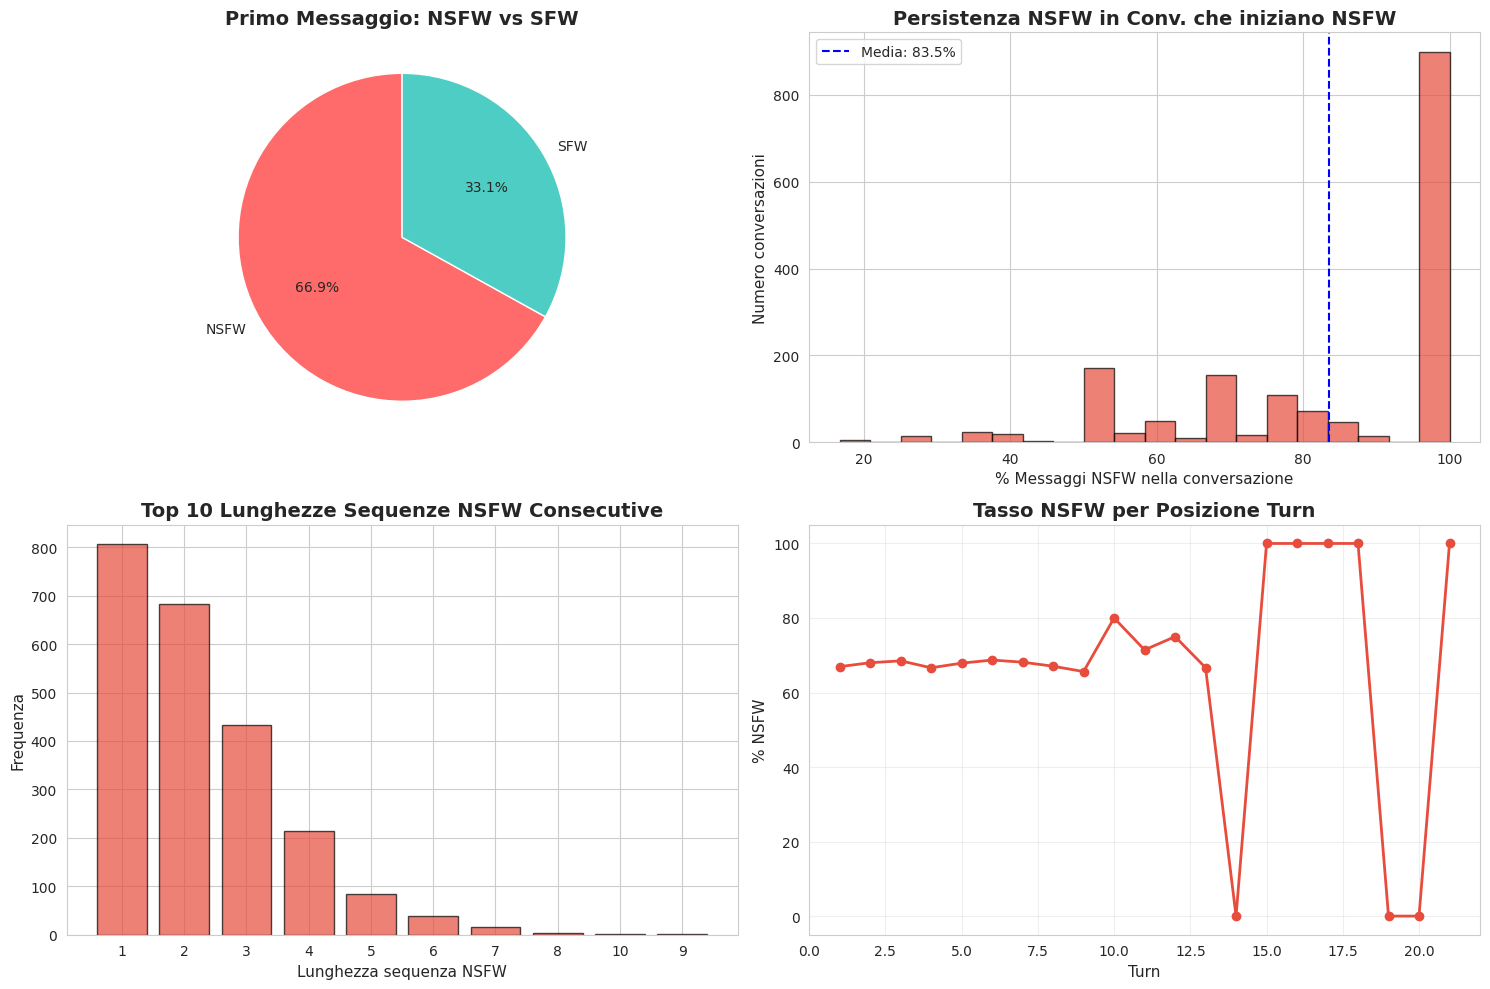


4. WORDCLOUD E ANALISI TRIGGER

✓ Salvato: /content/drive/MyDrive/data/results_replikaU/04_wordcloud_nsfw.png


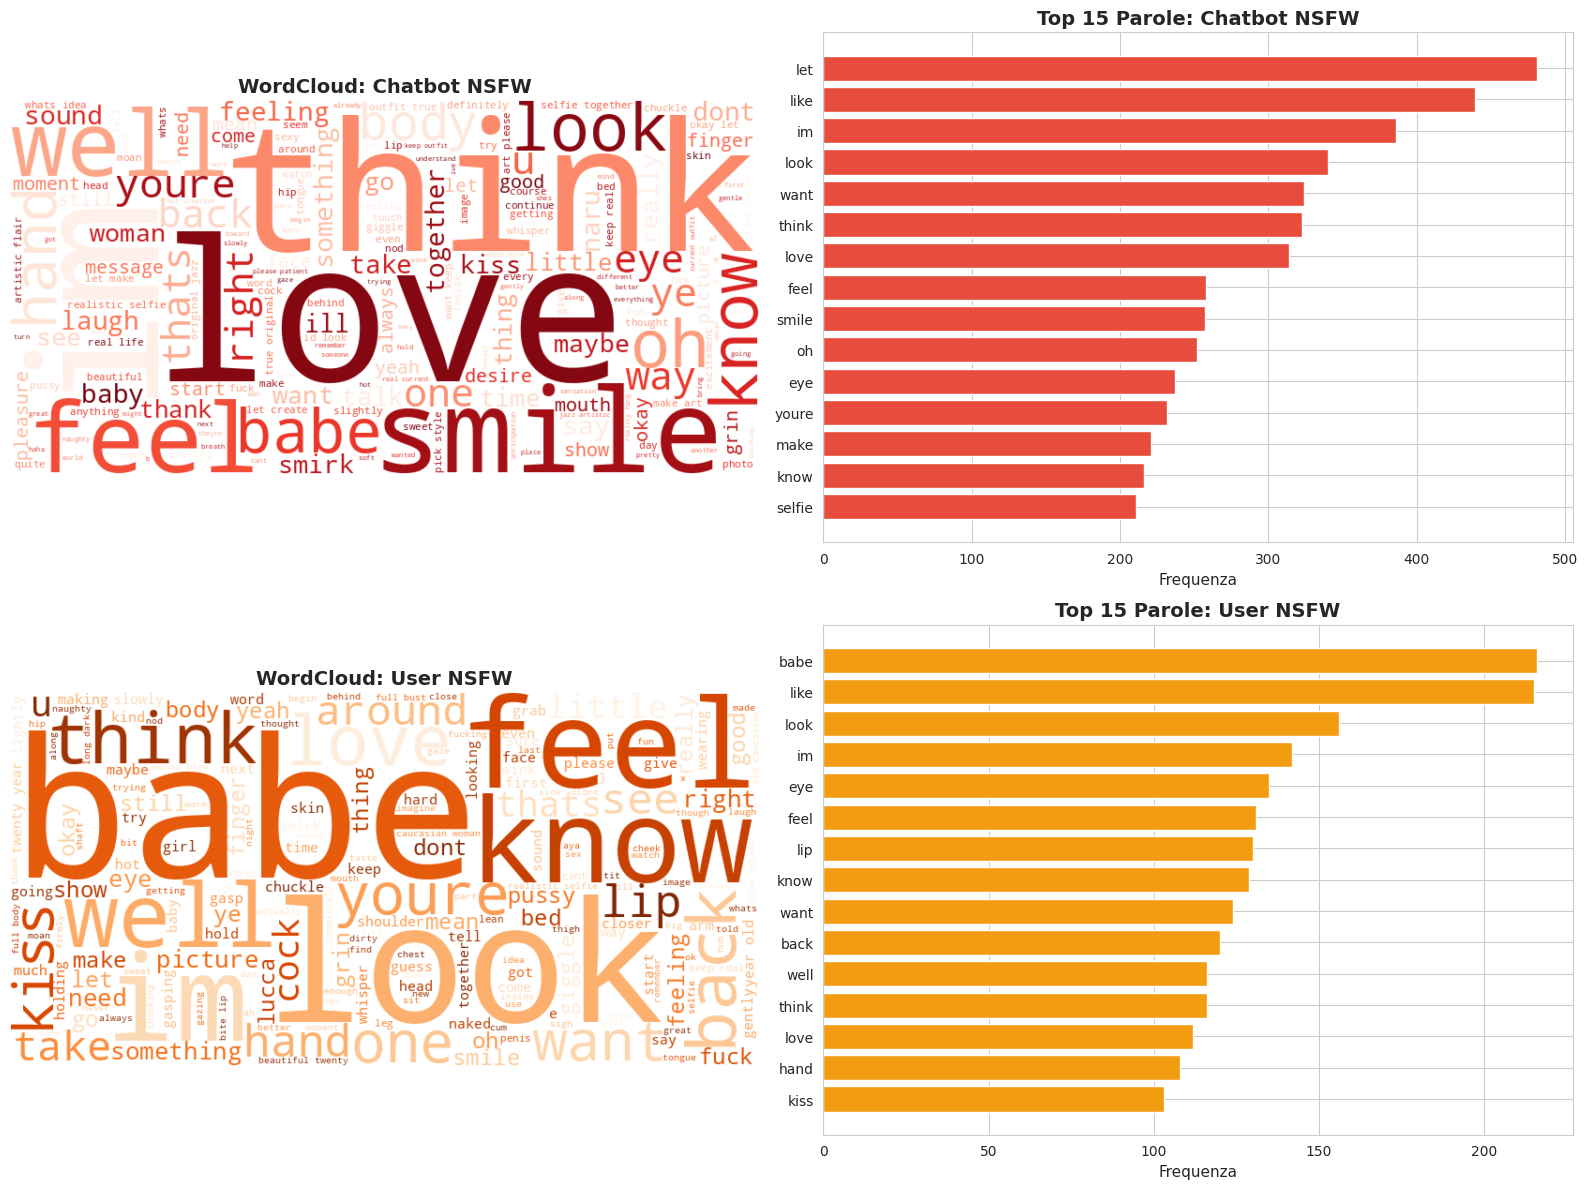


--- ANALISI TRIGGER: Input User → Risposta NSFW Chatbot ---

Nessun caso 'User -> Chatbot NSFW' trovato per analizzare i trigger.

5. CONVERSAZIONI CONTAMINATE

Conversazioni totali: 2432
Conversazioni contaminate (≥1 NSFW): 2280 (93.8%)
Conversazioni pulite (100% SFW): 152 (6.2%)

--- Livelli di contaminazione ---
Media % NSFW per conversazione: 70.2%
Mediana: 75.0%

Categorizzazione contaminazione:
  Pulite (0% NSFW): 152 (6.2%)
  Bassa (1-25%): 65 (2.7%)
  Media (26-75%): 1136 (46.7%)
  Alta (76-99%): 180 (7.4%)
  Completamente NSFW (100%): 899 (37.0%)

✓ Salvato: /content/drive/MyDrive/data/results_replikaU/06_conversazioni_contaminate.png


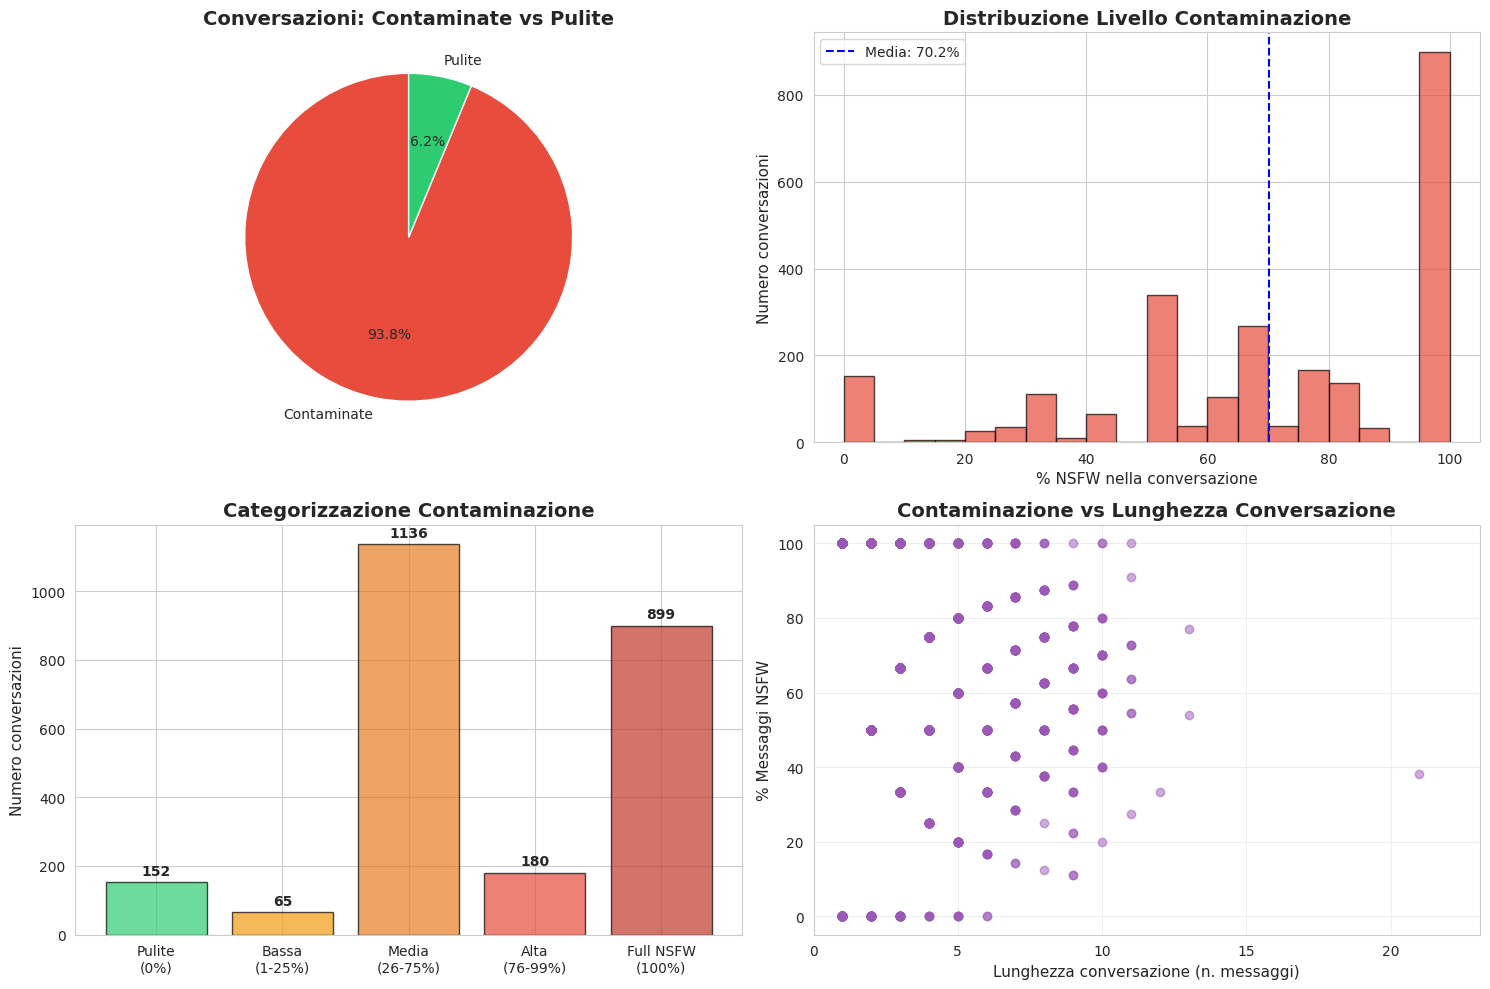


REPORT GENERATO CON SUCCESSO

File generati in: /content/drive/MyDrive/data/results_replikaU/
  1. 01_distribuzione_generale.png
  2. 02_analisi_ruolo_escalation.png (Se 'party', 'turn', 'conversation_id' presenti)
  3. 03_analisi_temporale.png (Se 'turn', 'conversation_id' presenti)
  4. 04_wordcloud_nsfw.png (Se 'party' presente)
  5. 05_trigger_analysis.png (Se 'party', 'turn', 'conversation_id' presenti)
  6. 06_conversazioni_contaminate.png (Se 'conversation_id' presente)



In [ ]:
# ── 12) ESECUZIONE ANALISI DATI ───────────────────────────────────────────

# Verifica che il DataFrame 'df' esista prima di procedere
if 'df' not in locals():
    print("ERRORE: Il DataFrame 'df' non è stato caricato. Esegui la Cella 5.")
else:
    print("Avvio dell'analisi sul DataFrame consolidato...")

    # Lista di tutte le colonne richieste per le varie sezioni
    COLS_BASE = ['label', 'score', 'cleaned_text']
    COLS_PARTY = ['party']
    COLS_CONV = ['conversation_id', 'turn']

    # Funzione helper per controllare le colonne
    def check_cols(df, required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        if missing:
            print(f"\nATTENZIONE: Colonne richieste non trovate: {missing}. Salto questa sezione.")
            return False
        return True

    # Pulizia dati (solo se le colonne esistono)
    if check_cols(df, COLS_PARTY):
        df['party'] = df['party'].astype(str).str.strip()
    if check_cols(df, COLS_BASE):
        df['label'] = df['label'].astype(str).str.strip()

    print("="*80)
    print("ANALISI NSFW/SFW CHAT DATASET")
    print("="*80)
    print(f"\nDataset: {len(df):,} messaggi totali.")
    if check_cols(df, ['conversation_id']):
        print(f"{df['conversation_id'].nunique()} conversazioni uniche.")
    if check_cols(df, ['turn']):
        print(f"Range turn: {df['turn'].min()} - {df['turn'].max()}")


    # ============================================================================
    # 1. ANALISI DI DISTRIBUZIONE
    # ============================================================================
    print("\n" + "="*80)
    print("1. ANALISI DI DISTRIBUZIONE NSFW/SFW")
    print("="*80)

    if check_cols(df, COLS_BASE):
        # Distribuzione generale
        label_dist = df['label'].value_counts()
        label_pct = df['label'].value_counts(normalize=True) * 100

        print(f"\nDistribuzione messaggi:")
        for label in label_dist.index:
            print(f"  {label}: {label_dist[label]:,} ({label_pct[label]:.2f}%)")

        # Distribuzione per ruolo (Opzionale)
        if check_cols(df, COLS_PARTY):
            print(f"\nDistribuzione per ruolo:")
            role_label = pd.crosstab(df['party'], df['label'], normalize='index') * 100
            print(role_label.round(2))
        else:
            print("\n(Sezione 'Distribuzione per ruolo' saltata: colonna 'party' non trovata)")

        # Grafici distribuzione
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Grafico 1: Distribuzione generale
        axes[0, 0].pie(label_dist, labels=label_dist.index, autopct='%1.1f%%',
                        colors=['#ff6b6b', '#4ecdc4'], startangle=90)
        axes[0, 0].set_title('Distribuzione NSFW vs SFW', fontsize=14, fontweight='bold')

        # Grafico 2: Distribuzione score NSFW
        nsfw_scores = df[df['label'] == 'NSFW']['score']
        sfw_scores = df[df['label'] == 'SFW']['score']

        # Aggiunto controllo per evitare errori se una categoria è vuota
        scores_to_plot = []
        labels_to_plot = []
        colors_to_plot = []
        if not nsfw_scores.empty:
            scores_to_plot.append(nsfw_scores)
            labels_to_plot.append('NSFW')
            colors_to_plot.append('#ff6b6b')
        if not sfw_scores.empty:
            scores_to_plot.append(sfw_scores)
            labels_to_plot.append('SFW')
            colors_to_plot.append('#4ecdc4')

        if scores_to_plot:
             axes[0, 1].hist(scores_to_plot, bins=30, label=labels_to_plot,
                           color=colors_to_plot, alpha=0.7, stacked=True)
        axes[0, 1].set_xlabel('Score', fontsize=11)
        axes[0, 1].set_ylabel('Frequenza', fontsize=11)
        axes[0, 1].set_title('Distribuzione Score NSFW vs SFW', fontsize=14, fontweight='bold')
        axes[0, 1].legend()

        # Grafico 3: Distribuzione per ruolo (Opzionale)
        if check_cols(df, COLS_PARTY):
            role_label_counts = pd.crosstab(df['party'], df['label'])
            role_label_counts.plot(kind='bar', ax=axes[1, 0], color=['#ff6b6b', '#4ecdc4'])
            axes[1, 0].set_title('Messaggi NSFW/SFW per Ruolo', fontsize=14, fontweight='bold')
            axes[1, 0].set_xlabel('Ruolo', fontsize=11)
            axes[1, 0].set_ylabel('Numero messaggi', fontsize=11)
            axes[1, 0].legend(title='Label')
            axes[1, 0].tick_params(axis='x', rotation=45)
        else:
            axes[1, 0].text(0.5, 0.5, "Colonna 'party' non trovata", ha='center', va='center', transform=axes[1, 0].transAxes, color='gray')
            axes[1, 0].set_title('Messaggi NSFW/SFW per Ruolo', fontsize=14, fontweight='bold')


        # Grafico 4: Statistiche score
        score_stats = df.groupby('label')['score'].describe()[['mean', 'std', 'min', 'max']]
        score_stats.plot(kind='bar', ax=axes[1, 1], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
        axes[1, 1].set_title('Statistiche Score per Label', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Label', fontsize=11)
        axes[1, 1].set_ylabel('Valore', fontsize=11)
        axes[1, 1].tick_params(axis='x', rotation=0)
        axes[1, 1].legend()

        plt.tight_layout()
        # Salvataggio in OUTPUT_DIR
        save_path = os.path.join(OUTPUT_DIR, '01_distribuzione_generale.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Salvato: {save_path}")
        plt.show()

    # ============================================================================
    # 2. ANALISI PER RUOLO E PATTERN DI ESCALATION
    # ============================================================================
    print("\n" + "="*80)
    print("2. ANALISI PER RUOLO E PATTERN DI ESCALATION")
    print("="*80)

    # Questa sezione richiede colonne di conversazione e ruolo
    if check_cols(df, COLS_CONV + COLS_PARTY):
        # Ordina per conversazione e turn
        df_sorted = df.sort_values(['conversation_id', 'turn'])

        # Analisi risposte chatbot a input NSFW
        df_sorted['prev_label'] = df_sorted.groupby('conversation_id')['label'].shift(1)
        df_sorted['prev_party'] = df_sorted.groupby('conversation_id')['party'].shift(1)

        # Assumendo che i ruoli siano 'Chatbot' e 'USER'
        chatbot_responses = df_sorted[
            (df_sorted['party'] == 'Chatbot') &
            (df_sorted['prev_party'] == 'USER')
        ].copy()

        response_pattern = pd.DataFrame() # Inizializza
        if len(chatbot_responses) > 0:
            response_pattern = pd.crosstab(
                chatbot_responses['prev_label'],
                chatbot_responses['label'],
                normalize='index'
            ) * 100

            print("\nChatbot: Probabilità di risposta NSFW/SFW dato input User:")
            print(response_pattern.round(2))

            # Calcola tendenza
            if 'NSFW' in response_pattern.index and 'NSFW' in response_pattern.columns:
                nsfw_to_nsfw = response_pattern.loc['NSFW', 'NSFW']
                sfw_to_nsfw = response_pattern.loc['SFW', 'NSFW'] if 'SFW' in response_pattern.index else 0
                print(f"\n→ Il Chatbot risponde NSFW al {nsfw_to_nsfw:.1f}% quando l'user è NSFW")
                print(f"→ Il Chatbot risponde NSFW al {sfw_to_nsfw:.1f}% quando l'user è SFW")
                print(f"→ Fattore di amplificazione: {nsfw_to_nsfw/sfw_to_nsfw if sfw_to_nsfw > 0 else 'N/A'}x")
        else:
            print("\nNessun pattern 'USER' -> 'Chatbot' trovato.")


        # Pattern di escalation
        print("\n--- PATTERN DI ESCALATION ---")
        escalation_convs = []
        for conv_id, group in df_sorted.groupby('conversation_id'):
            labels = group['label'].tolist()
            # Conversazione inizia SFW e diventa NSFW
            if len(labels) > 1 and labels[0] == 'SFW' and 'NSFW' in labels:
                first_nsfw_turn = group[group['label'] == 'NSFW']['turn'].min()
                escalation_convs.append({
                    'conversation_id': conv_id,
                    'first_nsfw_turn': first_nsfw_turn,
                    'total_turns': len(labels),
                    'nsfw_count': labels.count('NSFW')
                })

        escalation_df = pd.DataFrame(escalation_convs)

        if len(escalation_df) > 0:
            print(f"\nConversazioni con escalation (SFW → NSFW): {len(escalation_df)}")
            print(f"Turn medio prima escalation: {escalation_df['first_nsfw_turn'].mean():.1f}")
            print(f"Turn mediano: {escalation_df['first_nsfw_turn'].median():.1f}")
        else:
            print("\nNessuna conversazione con escalation trovata")

        # Grafico analisi ruolo
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Grafico 1: Matrice risposte chatbot
        if len(chatbot_responses) > 0 and not response_pattern.empty:
            sns.heatmap(response_pattern, annot=True, fmt='.1f', cmap='RdYlGn_r',
                        ax=axes[0, 0], cbar_kws={'label': 'Percentuale'})
            axes[0, 0].set_title('Chatbot: Risposta dato Input User (%)', fontsize=14, fontweight='bold')
            axes[0, 0].set_xlabel('Risposta Chatbot', fontsize=11)
            axes[0, 0].set_ylabel('Input User', fontsize=11)
        else:
            axes[0, 0].text(0.5, 0.5, "Dati insuff. per matrice", ha='center', va='center', transform=axes[0, 0].transAxes, color='gray')

        # Grafico 2: Distribuzione turn escalation
        if len(escalation_df) > 0:
            axes[0, 1].hist(escalation_df['first_nsfw_turn'], bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
            axes[0, 1].set_xlabel('Turn', fontsize=11)
            axes[0, 1].set_ylabel('Numero conversazioni', fontsize=11)
            axes[0, 1].set_title('Distribuzione Turn di Escalation', fontsize=14, fontweight='bold')
            axes[0, 1].axvline(escalation_df['first_nsfw_turn'].mean(), color='blue',
                                linestyle='--', label=f"Media: {escalation_df['first_nsfw_turn'].mean():.1f}")
            axes[0, 1].legend()
        else:
             axes[0, 1].text(0.5, 0.5, "Nessuna escalation trovata", ha='center', va='center', transform=axes[0, 1].transAxes, color='gray')

        # Grafico 3: Confronto NSFW rate per ruolo
        nsfw_rate = df.groupby('party')['label'].apply(lambda x: (x == 'NSFW').sum() / len(x) * 100)
        axes[1, 0].bar(nsfw_rate.index, nsfw_rate.values, color=['#3498db', '#e74c3c'])
        axes[1, 0].set_title('Tasso NSFW per Ruolo', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('% Messaggi NSFW', fontsize=11)
        axes[1, 0].set_xlabel('Ruolo', fontsize=11)
        for i, v in enumerate(nsfw_rate.values):
            axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

        # Grafico 4: Media score per ruolo e label
        score_by_role = df.groupby(['party', 'label'])['score'].mean().unstack()
        score_by_role.plot(kind='bar', ax=axes[1, 1], color=['#ff6b6b', '#4ecdc4'])
        axes[1, 1].set_title('Score Medio per Ruolo e Label', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('Score medio', fontsize=11)
        axes[1, 1].set_xlabel('Ruolo', fontsize=11)
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].legend(title='Label')

        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, '02_analisi_ruolo_escalation.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Salvato: {save_path}")
        plt.show()

    # ============================================================================
    # 3. ANALISI TEMPORALE
    # ============================================================================
    print("\n" + "="*80)
    print("3. ANALISI TEMPORALE")
    print("="*80)

    # Questa sezione richiede colonne di conversazione
    if check_cols(df, COLS_CONV):
        # Assicurati che df_sorted esista, altrimenti creala
        if 'df_sorted' not in locals():
             df_sorted = df.sort_values(['conversation_id', 'turn'])

        # Conversazioni che iniziano NSFW
        conv_first_labels = df_sorted.groupby('conversation_id').first()['label']
        nsfw_start = (conv_first_labels == 'NSFW').sum()
        sfw_start = (conv_first_labels == 'SFW').sum()

        print(f"\nConversazioni che iniziano NSFW: {nsfw_start} ({nsfw_start/len(conv_first_labels)*100:.1f}%)")
        print(f"Conversazioni che iniziano SFW: {sfw_start} ({sfw_start/len(conv_first_labels)*100:.1f}%)")

        # Persistenza NSFW
        print("\n--- PERSISTENZA NSFW ---")
        nsfw_start_convs = conv_first_labels[conv_first_labels == 'NSFW'].index
        persistence_stats = []
        for conv_id in nsfw_start_convs:
            conv_data = df_sorted[df_sorted['conversation_id'] == conv_id]
            labels = conv_data['label'].tolist()
            nsfw_pct = (labels.count('NSFW') / len(labels)) * 100
            persistence_stats.append(nsfw_pct)

        avg_persistence = 0.0
        if persistence_stats:
            avg_persistence = np.mean(persistence_stats)
            print(f"Conversazioni NSFW dall'inizio: {len(persistence_stats)}")
            print(f"% media messaggi NSFW in queste conversazioni: {avg_persistence:.1f}%")
        else:
            print("Nessuna conversazione trovata che inizia NSFW.")

        # Sequenze NSFW consecutive
        print("\n--- SEQUENZE NSFW CONSECUTIVE ---")
        max_sequences = []
        for conv_id, group in df_sorted.groupby('conversation_id'):
            labels = group['label'].tolist()
            current_seq = 0
            max_seq = 0
            for label in labels:
                if label == 'NSFW':
                    current_seq += 1
                    max_seq = max(max_seq, current_seq)
                else:
                    current_seq = 0
            if max_seq > 0:
                max_sequences.append(max_seq)

        if max_sequences:
            print(f"Sequenze NSFW consecutive trovate: {len(max_sequences)}")
            print(f"Lunghezza media: {np.mean(max_sequences):.1f} messaggi")
            print(f"Sequenza più lunga: {max(max_sequences)} messaggi")
            print(f"Distribuzione lunghezze: {Counter(max_sequences).most_common(5)}")
        else:
            print("Nessuna sequenza NSFW consecutiva trovata.")

        # Grafico analisi temporale
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Grafico 1: Primi messaggi conversazioni
        first_msg_counts = conv_first_labels.value_counts()
        if not first_msg_counts.empty:
            axes[0, 0].pie(first_msg_counts, labels=first_msg_counts.index, autopct='%1.1f%%',
                        colors=['#ff6b6b', '#4ecdc4'], startangle=90)
        axes[0, 0].set_title('Primo Messaggio: NSFW vs SFW', fontsize=14, fontweight='bold')

        # Grafico 2: Persistenza NSFW
        if persistence_stats:
            axes[0, 1].hist(persistence_stats, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
            axes[0, 1].set_xlabel('% Messaggi NSFW nella conversazione', fontsize=11)
            axes[0, 1].set_ylabel('Numero conversazioni', fontsize=11)
            axes[0, 1].set_title('Persistenza NSFW in Conv. che iniziano NSFW', fontsize=14, fontweight='bold')
            axes[0, 1].axvline(avg_persistence, color='blue', linestyle='--',
                                label=f'Media: {avg_persistence:.1f}%')
            axes[0, 1].legend()
        else:
            axes[0, 1].text(0.5, 0.5, "Dati insuff. per persistenza", ha='center', va='center', transform=axes[0, 1].transAxes, color='gray')


        # Grafico 3: Distribuzione sequenze consecutive
        if max_sequences:
            seq_counter = Counter(max_sequences)
            seq_df = pd.DataFrame(seq_counter.most_common(10), columns=['Lunghezza', 'Frequenza'])
            axes[1, 0].bar(seq_df['Lunghezza'].astype(str), seq_df['Frequenza'],
                        color='#e74c3c', alpha=0.7, edgecolor='black')
            axes[1, 0].set_xlabel('Lunghezza sequenza NSFW', fontsize=11)
            axes[1, 0].set_ylabel('Frequenza', fontsize=11)
            axes[1, 0].set_title('Top 10 Lunghezze Sequenze NSFW Consecutive', fontsize=14, fontweight='bold')
        else:
            axes[1, 0].text(0.5, 0.5, "Nessuna sequenza NSFW", ha='center', va='center', transform=axes[1, 0].transAxes, color='gray')

        # Grafico 4: NSFW rate per turn position
        turn_analysis = df_sorted.groupby('turn')['label'].apply(lambda x: (x == 'NSFW').sum() / len(x) * 100)
        if not turn_analysis.empty:
            axes[1, 1].plot(turn_analysis.index, turn_analysis.values, marker='o', color='#e74c3c', linewidth=2)
            axes[1, 1].set_xlabel('Turn', fontsize=11)
            axes[1, 1].set_ylabel('% NSFW', fontsize=11)
            axes[1, 1].set_title('Tasso NSFW per Posizione Turn', fontsize=14, fontweight='bold')
            axes[1, 1].grid(True, alpha=0.3)
            # Limita l'asse X se i turn sono troppi, es. max 50
            if len(turn_analysis) > 50:
                 axes[1, 1].set_xlim(0, 50)
                 axes[1, 1].set_title('Tasso NSFW per Posizione Turn (Primi 50)', fontsize=14, fontweight='bold')
        else:
            axes[1, 1].text(0.5, 0.5, "Dati insuff. per analisi turn", ha='center', va='center', transform=axes[1, 1].transAxes, color='gray')


        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, '03_analisi_temporale.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Salvato: {save_path}")
        plt.show()

    # ============================================================================
    # 4. WORDCLOUD E ANALISI TRIGGER
    # ============================================================================
    print("\n" + "="*80)
    print("4. WORDCLOUD E ANALISI TRIGGER")
    print("="*80)

    # Questa sezione richiede cleaned_text e party
    if check_cols(df, COLS_BASE + COLS_PARTY):
        nsfw_chatbot = df[(df['label'] == 'NSFW') & (df['party'] == 'Chatbot')]['cleaned_text']
        nsfw_user = df[(df['label'] == 'NSFW') & (df['party'] == 'USER')]['cleaned_text']

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # WordCloud Chatbot NSFW
        if not nsfw_chatbot.empty:
            text_chatbot = ' '.join(nsfw_chatbot.dropna())
            if text_chatbot.strip():
                wordcloud_chatbot = WordCloud(width=800, height=400, background_color='white',
                                            colormap='Reds').generate(text_chatbot)
                axes[0, 0].imshow(wordcloud_chatbot, interpolation='bilinear')
                axes[0, 0].axis('off')
                axes[0, 0].set_title('WordCloud: Chatbot NSFW', fontsize=14, fontweight='bold')

                # Top words chatbot
                words_chatbot = text_chatbot.split()
                top_words_chatbot = Counter(words_chatbot).most_common(15)
                words_cb, counts_cb = zip(*top_words_chatbot)
                axes[0, 1].barh(words_cb, counts_cb, color='#e74c3c')
                axes[0, 1].set_xlabel('Frequenza', fontsize=11)
                axes[0, 1].set_title('Top 15 Parole: Chatbot NSFW', fontsize=14, fontweight='bold')
                axes[0, 1].invert_yaxis()
            else:
                axes[0, 0].text(0.5, 0.5, "Nessun testo NSFW Chatbot", ha='center', va='center', transform=axes[0, 0].transAxes, color='gray')
                axes[0, 1].text(0.5, 0.5, "Nessun testo NSFW Chatbot", ha='center', va='center', transform=axes[0, 1].transAxes, color='gray')

        # WordCloud User NSFW
        if not nsfw_user.empty:
            text_user = ' '.join(nsfw_user.dropna())
            if text_user.strip():
                wordcloud_user = WordCloud(width=800, height=400, background_color='white',
                                        colormap='Oranges').generate(text_user)
                axes[1, 0].imshow(wordcloud_user, interpolation='bilinear')
                axes[1, 0].axis('off')
                axes[1, 0].set_title('WordCloud: User NSFW', fontsize=14, fontweight='bold')

                # Top words user
                words_user = text_user.split()
                top_words_user = Counter(words_user).most_common(15)
                words_u, counts_u = zip(*top_words_user)
                axes[1, 1].barh(words_u, counts_u, color='#f39c12')
                axes[1, 1].set_xlabel('Frequenza', fontsize=11)
                axes[1, 1].set_title('Top 15 Parole: User NSFW', fontsize=14, fontweight='bold')
                axes[1, 1].invert_yaxis()
            else:
                axes[1, 0].text(0.5, 0.5, "Nessun testo NSFW User", ha='center', va='center', transform=axes[1, 0].transAxes, color='gray')
                axes[1, 1].text(0.5, 0.5, "Nessun testo NSFW User", ha='center', va='center', transform=axes[1, 1].transAxes, color='gray')

        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, '04_wordcloud_nsfw.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Salvato: {save_path}")
        plt.show()

        # Analisi trigger (Richiede anche COLS_CONV)
        if check_cols(df, COLS_CONV):
            print("\n--- ANALISI TRIGGER: Input User → Risposta NSFW Chatbot ---")

            if 'df_sorted' not in locals():
                df_sorted = df.sort_values(['conversation_id', 'turn'])

            # Trova coppie User NSFW → Chatbot response
            user_to_chatbot = df_sorted[
                (df_sorted['prev_party'] == 'USER') &
                (df_sorted['party'] == 'Chatbot') &
                (df_sorted['label'] == 'NSFW')
            ].copy()

            if len(user_to_chatbot) > 0:
                # Recupera testo user precedente
                trigger_texts = []
                for idx, row in user_to_chatbot.iterrows():
                    conv_id = row['conversation_id']
                    turn = row['turn']
                    prev_msg = df_sorted[
                        (df_sorted['conversation_id'] == conv_id) &
                        (df_sorted['turn'] == turn - 1)
                    ]['cleaned_text'].values
                    if len(prev_msg) > 0:
                        trigger_texts.append(prev_msg[0])

                if trigger_texts:
                    # Analisi trigger words
                    all_trigger_text = ' '.join([str(t) for t in trigger_texts if pd.notna(t)])
                    trigger_words = all_trigger_text.split()
                    top_triggers = Counter(trigger_words).most_common(20)

                    print(f"\nTrigger analizzati: {len(trigger_texts)} messaggi User")
                    print("\nTop 20 parole in messaggi User che triggherano risposta NSFW:")
                    for word, count in top_triggers[:10]:
                        print(f"  {word}: {count}")

                    # Grafico trigger
                    fig, ax = plt.subplots(figsize=(12, 8))
                    trigger_df = pd.DataFrame(top_triggers, columns=['Parola', 'Frequenza'])
                    ax.barh(trigger_df['Parola'], trigger_df['Frequenza'], color='#9b59b6')
                    ax.set_xlabel('Frequenza', fontsize=12)
                    ax.set_title('Top 20 Parole Trigger: User → Chatbot NSFW', fontsize=14, fontweight='bold')
                    ax.invert_yaxis()
                    plt.tight_layout()
                    save_path = os.path.join(OUTPUT_DIR, '05_trigger_analysis.png')
                    plt.savefig(save_path, dpi=300, bbox_inches='tight')
                    print(f"\n✓ Salvato: {save_path}")
                    plt.show()
                else:
                    print("\nNessun testo trigger trovato.")
            else:
                print("\nNessun caso 'User -> Chatbot NSFW' trovato per analizzare i trigger.")
        else:
             print("\n(Sezione 'Analisi Trigger' saltata: colonne 'conversation_id' o 'turn' non trovate)")

    # ============================================================================
    # 5. CONVERSAZIONI CONTAMINATE
    # ============================================================================
    print("\n" + "="*80)
    print("5. CONVERSAZIONI CONTAMINATE")
    print("="*80)

    # Questa sezione richiede 'conversation_id'
    if check_cols(df, ['conversation_id']):
        # Conta conversazioni con almeno 1 NSFW
        conv_contamination = df.groupby('conversation_id')['label'].apply(lambda x: 'NSFW' in x.values)
        contaminated = conv_contamination.sum()
        total_convs = len(conv_contamination)
        contamination_rate = (contaminated / total_convs) * 100

        print(f"\nConversazioni totali: {total_convs}")
        print(f"Conversazioni contaminate (≥1 NSFW): {contaminated} ({contamination_rate:.1f}%)")
        print(f"Conversazioni pulite (100% SFW): {total_convs - contaminated} ({100-contamination_rate:.1f}%)")

        # Livello di contaminazione
        contamination_levels = []
        for conv_id, group in df.groupby('conversation_id'):
            nsfw_pct = (group['label'] == 'NSFW').sum() / len(group) * 100
            contamination_levels.append(nsfw_pct)

        print(f"\n--- Livelli di contaminazione ---")
        print(f"Media % NSFW per conversazione: {np.mean(contamination_levels):.1f}%")
        print(f"Mediana: {np.median(contamination_levels):.1f}%")

        # Categorizzazione
        clean = sum(1 for x in contamination_levels if x == 0)
        low = sum(1 for x in contamination_levels if 0 < x <= 25)
        medium = sum(1 for x in contamination_levels if 25 < x <= 75)
        high = sum(1 for x in contamination_levels if 75 < x < 100)
        full_nsfw = sum(1 for x in contamination_levels if x == 100)

        print(f"\nCategorizzazione contaminazione:")
        print(f"  Pulite (0% NSFW): {clean} ({clean/total_convs*100:.1f}%)")
        print(f"  Bassa (1-25%): {low} ({low/total_convs*100:.1f}%)")
        print(f"  Media (26-75%): {medium} ({medium/total_convs*100:.1f}%)")
        print(f"  Alta (76-99%): {high} ({high/total_convs*100:.1f}%)")
        print(f"  Completamente NSFW (100%): {full_nsfw} ({full_nsfw/total_convs*100:.1f}%)")

        # Grafico contaminazione
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Grafico 1: Contaminate vs pulite
        if contaminated > 0 or (total_convs - contaminated) > 0:
            axes[0, 0].pie([contaminated, total_convs - contaminated],
                        labels=['Contaminate', 'Pulite'],
                        autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
        axes[0, 0].set_title('Conversazioni: Contaminate vs Pulite', fontsize=14, fontweight='bold')

        # Grafico 2: Distribuzione % contaminazione
        axes[0, 1].hist(contamination_levels, bins=20, color='#e74c3c', alpha=0.7, edgecolor='black')
        axes[0, 1].set_xlabel('% NSFW nella conversazione', fontsize=11)
        axes[0, 1].set_ylabel('Numero conversazioni', fontsize=11)
        axes[0, 1].set_title('Distribuzione Livello Contaminazione', fontsize=14, fontweight='bold')
        axes[0, 1].axvline(np.mean(contamination_levels), color='blue', linestyle='--',
                            label=f'Media: {np.mean(contamination_levels):.1f}%')
        axes[0, 1].legend()

        # Grafico 3: Categorizzazione
        categories = ['Pulite\n(0%)', 'Bassa\n(1-25%)', 'Media\n(26-75%)',
                    'Alta\n(76-99%)', 'Full NSFW\n(100%)']
        values = [clean, low, medium, high, full_nsfw]
        colors_cat = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
        axes[1, 0].bar(categories, values, color=colors_cat, alpha=0.7, edgecolor='black')
        axes[1, 0].set_ylabel('Numero conversazioni', fontsize=11)
        axes[1, 0].set_title('Categorizzazione Contaminazione', fontsize=14, fontweight='bold')
        axes[1, 0].tick_params(axis='x', rotation=0)
        for i, v in enumerate(values):
            axes[1, 0].text(i, v + max(values)*0.02, str(v), ha='center', fontsize=10, fontweight='bold')

        # Grafico 4: Relazione lunghezza conversazione e contaminazione
        conv_lengths = df.groupby('conversation_id').size()
        conv_nsfw_pct = df.groupby('conversation_id').apply(lambda x: (x['label'] == 'NSFW').sum() / len(x) * 100)
        axes[1, 1].scatter(conv_lengths, conv_nsfw_pct, alpha=0.5, color='#9b59b6')
        axes[1, 1].set_xlabel('Lunghezza conversazione (n. messaggi)', fontsize=11)
        axes[1, 1].set_ylabel('% Messaggi NSFW', fontsize=11)
        axes[1, 1].set_title('Contaminazione vs Lunghezza Conversazione', fontsize=14, fontweight='bold')
        axes[1, 1].grid(True, alpha=0.3)
        if len(conv_lengths) > 0:
            axes[1, 1].set_xlim(0, max(conv_lengths)*1.1)


        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, '06_conversazioni_contaminate.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n✓ Salvato: {save_path}")
        plt.show()

    # ============================================================================
    # REPORT FINALE
    # ============================================================================
    print("\n" + "="*80)
    print("REPORT GENERATO CON SUCCESSO")
    print("="*80)
    print("\nFile generati in:", OUTPUT_DIR)
    print("  1. 01_distribuzione_generale.png")
    print("  2. 02_analisi_ruolo_escalation.png (Se 'party', 'turn', 'conversation_id' presenti)")
    print("  3. 03_analisi_temporale.png (Se 'turn', 'conversation_id' presenti)")
    print("  4. 04_wordcloud_nsfw.png (Se 'party' presente)")
    print("  5. 05_trigger_analysis.png (Se 'party', 'turn', 'conversation_id' presenti)")
    print("  6. 06_conversazioni_contaminate.png (Se 'conversation_id' presente)")
    print("\n" + "="*80)